PROBLEMI DELLE RNN

Immagina di voler scrivere un romanzo, bisogna ricordare che era il protagonista 100 pagine prima.

- Il concetto di memoria a breve termine, come la rete prova a tenere traccia del passato con lo strato nascosto
- Scomparsa del gradiente
- I modelli soffronto di amnesia quando le informazioni sono distanti tra loro

Memoria a Breve Termine e Stato Nascosto
Come le RNN conservano l'informazione locale.
Le reti neurali ricorrenti introducono un loop interno che permete all'informazione di persistere. Questo meccanismo trasforma lo stato attuale della rete in una funzione non solo dell'input corrente, ma anche del passato immediato.
Tuttavia questa memoria è volatile. Lo 'stato nascosto' agisce come una lavagna che viene parzialmente cancellata e riscritta a ogni passo temporale, rendendo difficile la conservazione di dettagli remoti.

Anatomia della Ricorsione
Sincronizzazione tra passasto e presente
Lo stato nascosto è il vettore che evolve nel tempo.
- Hidden State: il vettore che funge da memoria interna, aggiornato dinamicamente per ogni elemento della sequenza temporale.
- Parametri Condivisi: a differenza delle reti dense, la stessa matrice di pesi (la stessa logica) viene applicata a ogni passo temporale, riducnedo drasticamente il numero di parametri. E' come se avessim un unico dipendente che gestisce i clienti sempre nello stesso modo.
- Unrolling: il processo logico di srotolamento della rete lungo la dimensione temporale per visualizzare il flusso dei dati
- Aggiornamento dello stato: la computazione che combina l'input attuale con lo stato precedente tramite una funzione di attivazione non lineare.
Lo stato attuale nasce da un mix tra passato (h (t-1) e il presente x(t))

Perche èsiamo la funzione tangente e non la Relu (più usata nelle CNN)?

Dinamiche della Memoria Ricorrente
In un ciclo ricorsivo, i valori vengono moltiplicati continuamente, se avessi una funzione che non schiaccia i valori, questo potrebbero esplodere all'inifito. La Tanh li schiaccia tra -1 e 1
L'uso della Tanh:La funzione tangente iperbolica è preferita per regolare lo stasto nascosto, mantenendo i valori tra -1 e 1 ed evitando che le attivazioni esplodano durante i cicli
Inizializzazione dello Stato: al tempo zero, lo stsato nascoste viene solitamente inizializzato con un vettore di zeri, rappresentando una tabula rasa prima dell'inizio della sequenza
Persistenza Locale: la rete è eccellente nel correlare eventi molto vicini tra loro, rendendola ideale per pattern fonetici o variazioi di borsa ad alta frequenza.

Ma una memoria è utile solo se produce risultato

Predizione dell'Output
Dallo stato interno al risultato finale.
Una volta calcolato lo stato nascosto, la rete può produrre un output per ogni passo temporale o solo alla fine delle sequenza, trasformando quello che la rete ha in mente, in una predizione. Questa trasformazione è lineare. Questo output è frutto di una trasformazione lineare dello stato corrente.
La matrice di pesi per l'output rimane costante per tutta la durata della sequenza, garantendo coerenza nella mappatura tra memoria e predizione.
Tutto sembra perfetto fino a quando non proviamo ad addestrare la rete su sequenze lunghe, è qui che iniziano i guai.

La Scompara del Gradiente
Il limite matematico dell'addestramento temporale.
L'addestramento di una RNN avviene tramite 'Backpropagation Through Time' (BPTT).
Immagina di dover correggere un errore fatto alla fine di un percorso a ritroso. L'errore deve viaggiare nel tempo tornando indietro di 10,20, 100 passi, ma qui la matematica non ci viene in aiuto, perchè per tornare indietro dobbiamo moltiplicare gli errori, e se gli errori sono piccoli, dopo 100 passi non ci rimane praticamente nulla (l'errore svanisce)

Instabiltà del Gradiente
Perchè l'errore svanisce nel tempo
- BPTT: è l'algoritmo che estende la retro-propagazione standard calcoland i gradienti su una rete srotolata
- Chain Rule Temporale: è la regola matematica che richiede la moltiplicazione delle matrici di pesi per ogni passo del passato.
Per calcolare come l'inizio influenzi la fine, dobbiamo moltiplicare le derivate di ogni singolo passo intermedio. Se il peso è minore di 1 il gradiente svanisce, se è maggiore di 1 esplode. E' come il gioco del telefono senza fili.
- Vanisching Gradient: è il fenomeno per cui il segnale dell'errore diminuisce esponenzialmente man mano che si torna indietro nel tempo
- Exploding Gradient: è il problema opposto, dove il gradiente cresce in modo incontrollato, portando a pesi NaN e instabiltà numerica.

Conseguenze sull'Apprendimento (del vanisching gradient)
- Inerzia dei pesi: I pesi associati agli input iniziali smettono di cambiare, lascindo la rete incapace di adattarsi a informazioni che appaiono all'inizio di una lunga sequenza.
I neuroni che dovrebbero imparare dall'inizio della frase, smettono di aggiornarsi. La rete sviluppa un bias verso il presente, da molto importanza alle ultime due parole lette, ma va a ignorare il contesto iniziale.
- Bias verso il Presente: la rete ottimizza solo i pattern più recenti, poichè il gradiente è ancora abbastanza forte da guidare l'aggiornamento dei parametri solo negli ultimi passi.
- Gradient Clipping: una tecnica di emergenza che consiste nel tagliare il valore del gradiente se supera una carta soglia, utile per mitigare l'esplosione ma inutile contro la scomparsa

Il colpevole specifico di tutto questo è la nostra funzione di attivazione.

Effetto della Funzione di Attivazione
Il ruolo della derivata della Tanh
La derivata della fuzione 'tanh' è sempre minore o uguale a 1. 
La derivata della tanh ha un picco massi mo di 1, ma per la maggior parte del tempo è molto più piccola. Moltiplicare i numeri minori di 1 per decine di volte è la ricetta perfetta per lo zero. Ed è qui che cade il limite strutturale delle RNN classiche.
Quando moltiplichiamo queste derivate per molti passi temporali, il prodotto decade rapidamente verso lo zero.
Questa proprietà è intrinseca alle architetture ricorrenti classiche e rappresenta il principale ostacolo alla creazione di modelli a memoria profonda.

Difficoltà con le Dipendenze Distanti.
Il gap informativo nelle sequenze reali.
In molte applicazioni, l'informazione necessaria per interpretare un dati si trova molto indietro nel tempo. Ad esempio, il soggetto di una frase lunga determina la declinazione di un verbo posto alla fine della frase.
L'inizio di una frase spesso decide la fine. se dico; "le chiavi che erano vicino alla finestra" il verbo finale dove essere plurale perchè le chiavi (all'inizio delle frase) sono plurali.
A causa dei problemi di gradiente, le RNN base falliscono nel collegare questi punti distanti, soffrendo di  una sorta di amnesia per tutto ciò che non è accaduto negli ultimi isanti.
Questo è il fallimento della dipendenza a lungo termine.

Ma perchè l'informazione si perde in questo modo:

Long-Time Dependencies
Il fallimento della memoria a lungo termine.
- Intervallo di Dipendenza: è la distanza temporale tra un input rilevante e il punto in cui quell'informazione deve essere utilizzata
- Diluizione del Segnale: 'informazione utile viene mescolata con input successivi irrilevanti, perdendo la sua identità nello stato nascosto.
- Rumore Sequenziale: ogni nuovo passo temporale introduce potenzialmente interferenze che degradano la memoria dei passi precedenti.
- Limidi di Architettura: la struttura fissa di aggiornamento non permette di saltare passi o proteggere selettivamente informazioni critiche.
Ogni parole irrilevante in una frase è sostanzialmente 'rumore' che si mescola nello strato nascosto
Esempio nella frese di prima "le chiavi che erano vicino alla finestra" parole come "le", "alla" sono irrilevanti. Senza un metodo per proteggere le informazioni importanti queste vengono sovrascritte dai dati nuovi (quindi anche informazioni irrilevanti) e la struttura fissa delle RNN di base non permetti salti, devi processare tutto.

Esempi di Fallimento
- Contesto del Testo: se una frase inizia con 'le chiavi che ho perso ieri nel parco...' la rete potrebbe dimenticare il genere plurale quando deve generare il verbo molti token dopo
- Serie Temporali Complesse: pattern stagionali (es. vendite annuali) sono difficili da catturare per una RNN base che si concentra solo sui giorni immediatamente precedenti
- Segnali Audio: la compressione del senso di un discorso richiede di collegare parole pronunciate all'inizio di un paragrafo, un compito arduo per la ricorsione semplice.
In tutti questi casi una simple RNN si comporta dimenticandosi l'inizio della frase o del discorso.

Ma esiste una via d'uscita da questi gradienti scomparsi?

Verso soluzioni più avanzate.
La necessità di un'auotstrada dell'informazione.
Per risolvere questi limiti, la ricerca si è spostata verso architetture che permettono al gradiente di fluire senza ostacoli, come se esistesse un tunnel che collega il passato al presente.
Servono dei meccanismi per decidere cosa scrivere sulla lavagna e proteggere dalla cancellazione. Qui nascono i concetti di gating.
Senza meccanismi di gating (porte), lo stato nascosto è vittima di una sovrascrittura continua che distrugge la casualità a lungo termine.
Vedremo i gating più avanti ora facciamo un esempio di RNN originale


--- Testando sequenza di lunghezza: 10 ---
Accuratezza finale su test: 1.0000

--- Testando sequenza di lunghezza: 30 ---
Accuratezza finale su test: 0.8640

--- Testando sequenza di lunghezza: 50 ---
Accuratezza finale su test: 0.4740

--- Testando sequenza di lunghezza: 70 ---
Accuratezza finale su test: 0.8880


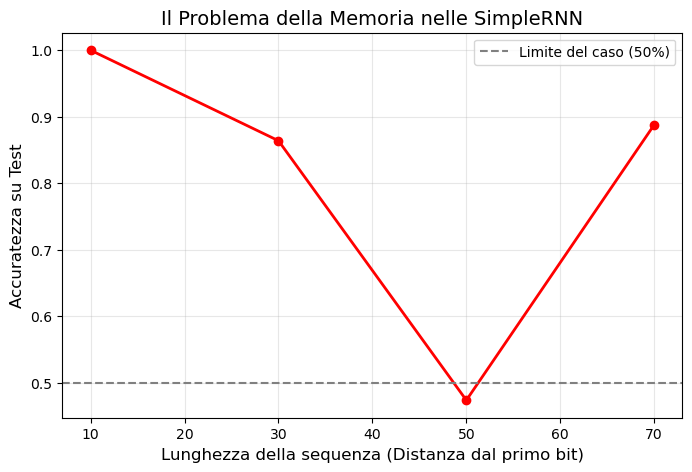

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# =================================================================
# 1. GENERAZIONE DEL DATASET (The "Remember the First Bit" Task)
# =================================================================
def generate_data(n_samples, seq_len):
    """
    Questo task è ingannevolmente semplice ma brutalmente difficile per una RNN.
    La rete deve guardare una sequenza e ignorare tutto tranne il primissimo elemento.
    
    Perché è un test di memoria? 
    Perché per predire correttamente alla fine della sequenza (passo T), 
    l'informazione del passo 0 deve sopravvivere a T moltiplicazioni matriciali.
    """
    # Generiamo dati casuali: (campioni, passi_temporali, feature)
    # Le RNN in Keras si aspettano sempre un input 3D.
    X = np.random.randint(0, 2, size=(n_samples, seq_len, 1)).astype('float32')
    
    # Il target (y) è il primo bit di ogni sequenza: X[tutti i campioni, tempo 0, feature 0]
    # Se il primo bit è 1, y è 1. Se è 0, y è 0.
    y = X[:, 0, 0]
    return X, y

# =================================================================
# 2. CONFIGURAZIONE DELL'ESPERIMENTO
# =================================================================
# Testiamo come si comporta la rete all'aumentare della distanza temporale.
seq_lengths = [10, 30, 50, 70] 
results = {}

for length in seq_lengths:
    print(f"\n--- Testando sequenza di lunghezza: {length} ---")
    
    X_train, y_train = generate_data(2000, length)
    X_test, y_test = generate_data(500, length)
    
    # ARCHITETTURA DEL MODELLO
    # Utilizziamo una SimpleRNN. A differenza delle LSTM, la SimpleRNN non ha 
    # le "porte" (gates) per proteggere il flusso dell'informazione.
    model = models.Sequential([
        # Shape: (Lunghezza variabile della sequenza, 1 feature)
        layers.Input(shape=(length, 1)),
        
        # 16 unità: lo stato nascosto h_t è un vettore di 16 numeri.
        # Activation 'tanh': comprime i valori tra -1 e 1 ad ogni passo temporale.
        layers.SimpleRNN(16, activation='tanh'), 
        
        # Sigmoid: trasforma l'output finale in una probabilità tra 0 e 1.
        layers.Dense(1, activation='sigmoid')
    ])
    
    # Compilazione: usiamo binary_crossentropy perché è un problema di classificazione 0/1.
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # TRAINING
    # Nota: con verbose=0 non stampiamo il progresso, per pulizia della console.
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, 
                        validation_data=(X_test, y_test), verbose=0)
    
    # Recuperiamo l'accuratezza finale sul test set
    final_acc = history.history['val_accuracy'][-1]
    results[length] = final_acc
    print(f"Accuratezza finale su test: {final_acc:.4f}")

# =================================================================
# 3. VISUALIZZAZIONE DEL CROLLO DELLA MEMORIA
# =================================================================
# Analisi del grafico:
# Viene mostrata l'accuratezza in funzione della lunghezza della sequenza.
# - Vicino a 1.0 (100%): La rete ricorda il primo bit.
# - Vicino a 0.5 (50%): La rete sta tirando a indovinare (Random Guessing).
#   Questo accade perché l'informazione del primo bit è "svanita" durante il tragitto.

plt.figure(figsize=(8, 5))
plt.plot(list(results.keys()), list(results.values()), marker='o', color='red', linewidth=2)
plt.title("Il Problema della Memoria nelle SimpleRNN", fontsize=14)
plt.xlabel("Lunghezza della sequenza (Distanza dal primo bit)", fontsize=12)
plt.ylabel("Accuratezza su Test", fontsize=12)
plt.axhline(y=0.5, color='gray', linestyle='--', label="Limite del caso (50%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Lo stato nascosto è molto potente ma fragile.
per questo le RNN base non riesco ad imparare contesti lunghi.
